In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.12.0


In [4]:
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'age', 'sex', 'fare', 'embarked']].dropna()
df['sex']      = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print(df.shape)
print(df.head())
print(df.isnull().sum())

(712, 6)
   survived  pclass   age  sex     fare  embarked
0         0       3  22.0    0   7.2500         0
1         1       1  38.0    1  71.2833         1
2         1       3  26.0    1   7.9250         0
3         1       1  35.0    1  53.1000         0
4         0       3  35.0    0   8.0500         0
survived    0
pclass      0
age         0
sex         0
fare        0
embarked    0
dtype: int64


In [7]:
X = df.drop('survived', axis = 1).values #.values converts to numpy array
y = df['survived'].values

#scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

#Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")

Training samples: 569
Testing samples:  143
Features:         5


In [23]:
#convert NumPy arrays to PyTorch arrays

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t = torch.FloatTensor(y_test)

print(f"X_train tensor shape: {X_train_t.shape}")
print(f"y_train tensor shape: {y_train_t.shape}")
print(f"Data type: {X_train_t.dtype}")

X_train tensor shape: torch.Size([569, 5])
y_train tensor shape: torch.Size([569])
Data type: torch.float32


In [24]:
class TitanicNet(nn.Module):
    def __init__(self):
        super(TitanicNet, self).__init__()

        self.layer1 = nn.Linear(5, 16)
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 1) 

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return X

model = TitanicNet()
print(model)
print(f"\n Total parameters: {sum(p.numel() for p in model.parameters())}")

TitanicNet(
  (layer1): Linear(in_features=5, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

 Total parameters: 241


In [25]:
#loss function
criterion = nn.BCELoss()

#optimizer updates weight with gradient descent
optimizer = optim.Adam(model.parameters(), lr = 0.001)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")


Loss function: BCELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [26]:
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()

    #step 1: forward pass
    predictions = model(X_train_t).squeeze()

    #step 2: calculation loss
    loss = criterion(predictions, y_train_t)

    #step 3: backpass (backpropagation)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #record loss
    train_loss.append(loss.item())

    #print every 10 epochs
    if (epochs % 10) == 0:
        print(f"Epoch {epoch+1:3d}/100 | loss {loss.item():.4f}")


TypeError: 'int' object is not callable

In [27]:
print(f"X_train_t dtype: {X_train_t.dtype}")
print(f"y_train_t dtype: {y_train_t.dtype}")
print(f"X_train_t shape: {X_train_t.shape}")
print(f"y_train_t shape: {y_train_t.shape}")

# Test one forward pass
test_pred = model(X_train_t).squeeze()
print(f"Prediction shape: {test_pred.shape}")
print(f"Prediction dtype: {test_pred.dtype}")

X_train_t dtype: torch.float32
y_train_t dtype: torch.float32
X_train_t shape: torch.Size([569, 5])
y_train_t shape: torch.Size([569])
Prediction shape: (712, 5)
Prediction dtype: float64


In [28]:
print(type(model))

<class '__main__.TitanicNet'>


In [29]:
# Recreate model fresh
model = TitanicNet()

# Recreate loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Test forward pass
with torch.no_grad():
    test_pred = model(X_train_t).squeeze()
    print(f"Prediction shape: {test_pred.shape}")
    print(f"Prediction dtype: {test_pred.dtype}")
    print(f"y_train_t shape:  {y_train_t.shape}")
    print(f"y_train_t dtype:  {y_train_t.dtype}")

Prediction shape: (712, 5)
Prediction dtype: float64
y_train_t shape:  torch.Size([569])
y_train_t dtype:  torch.float32


In [30]:
import torch
import torch.nn as nn

# Check if nn is correct
print(type(nn.Linear))

# Rebuild model completely
class TitanicNet(nn.Module):
    def __init__(self):
        super(TitanicNet, self).__init__()
        self.layer1 = nn.Linear(5, 16)
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 1)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x

model = TitanicNet()

# Test immediately
with torch.no_grad():
    out = model(X_train_t)
    print(f"Raw output shape: {out.shape}")
    print(f"Squeezed shape:   {out.squeeze().shape}")

<class 'type'>
Raw output shape: torch.Size([569, 1])
Squeezed shape:   torch.Size([569])


In [31]:
# Fresh loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 100
train_losses = []

for epoch in range(epochs):
    model.train()
    
    # Forward pass
    predictions = model(X_train_t).squeeze()
    
    # Calculate loss
    loss = criterion(predictions, y_train_t)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/100 | Loss: {loss.item():.4f}")

Epoch  10/100 | Loss: 0.6572
Epoch  20/100 | Loss: 0.6461
Epoch  30/100 | Loss: 0.6337
Epoch  40/100 | Loss: 0.6187
Epoch  50/100 | Loss: 0.6018
Epoch  60/100 | Loss: 0.5828
Epoch  70/100 | Loss: 0.5626
Epoch  80/100 | Loss: 0.5421
Epoch  90/100 | Loss: 0.5224
Epoch 100/100 | Loss: 0.5041


In [32]:
# Train for 500 more epochs
epochs = 500

for epoch in range(epochs):
    model.train()
    predictions = model(X_train_t).squeeze()
    loss = criterion(predictions, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+101:3d}/600 | Loss: {loss.item():.4f}")

Epoch 200/600 | Loss: 0.4116
Epoch 300/600 | Loss: 0.3959
Epoch 400/600 | Loss: 0.3877
Epoch 500/600 | Loss: 0.3816
Epoch 600/600 | Loss: 0.3751


Test Accuracy: 0.7972


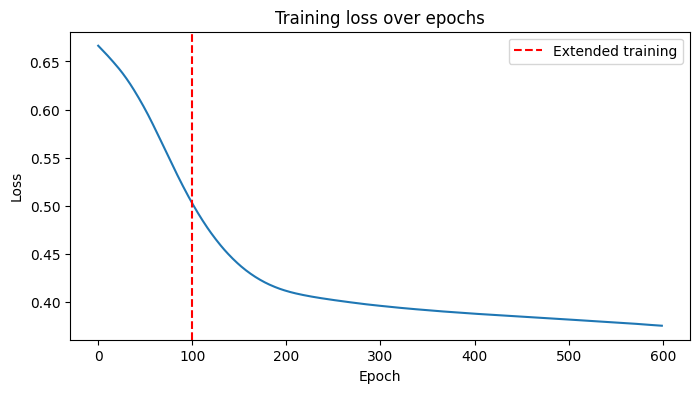

In [33]:
# Evaluate
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_t).squeeze()
    test_pred_binary = (test_predictions >= 0.5).float()
    accuracy = (test_pred_binary == y_test_t).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title('Training loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.axvline(x=100, color='red', linestyle='--', label='Extended training')
plt.legend()
plt.show()
